In [7]:
include("QFactorOOO.jl")
using Plots
using ProgressMeter

In [17]:
l1=3
l2=3
l=3
m1=3
m2=-3
ω1=0.1
ω2=0.3

rmin=6.0
rmax=10^4;

### Source Asymptotics

In [3]:
sol1 = linear_sol(l1, ω1, "odd", rmin, rmax);
sol2 = linear_sol(l2, ω2, "odd", rmin, rmax);

aux = collect(-6.0:0.01:4.0)
r_vals = @. 2.0 + 10^aux
a_src = zeros(length(r_vals))
b_src = zeros(length(r_vals))

for (i,r) in enumerate(r_vals)
    a_src[i] = abs.(SOOO(sol1, sol2, ω1, ω2, l1, l2, l, m1, m2, r))
    b_src[i] = abs.(SOOO_bruno(sol1, sol2, ω1, ω2, l1, l2, l, m1, m2, r))
end

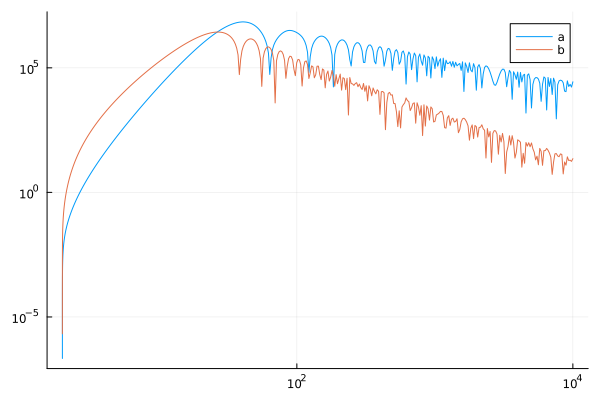

In [16]:
plot(r_vals, a_src, xscale=:log10, yscale=:log10, label="a")
plot!(r_vals, b_src, xscale=:log10, yscale=:log10, label="b")

In [4]:
function rs(r)
    return @. r+2*log(r/2-1)
end

rs_vals = rs(r_vals)

open("../data/source_ooo.dat", "w") do IO
    write(IO,"rs sa sb close far1 far2\n")
    for (r,rt,s,sb) in zip(r_vals,rs_vals, a_src, b_src)
        fitfar = 1e8/r^2
        fitfar2 = 1e7/r
        write(IO,"$(rt) $(s) $(sb) $(2*(r-2)) $(fitfar) $(fitfar2)\n")
    end
end

### Convergence of Q vs w

In [33]:
Λ=4.0
# qa=abs(qfactor_ooo(ω1, ω2, l1, l2, l, m1, m2, rmin=Λ+1, rmax=10^(Λ-1)/ω1, source="adrien"))
qb=abs(qfactor_ooo(0.45, 0.5, l1, l2, l, m1, m2, rmin=Λ+1, rmax=10^(Λ-1), source="bruno"))
# println("Q factor (Adrien source): ", qa)
println("Q factor (Bruno source): ", qb)

Q factor (Bruno source): 0.9751671900150828



In [ ]:
l_vals = collect(3.0:0.2:5.0)
ω_vals = collect(0.1:0.2:0.71)
qa_vals = zeros((length(ω_vals), length(l_vals)))
qb_vals = zeros((length(ω_vals), length(l_vals)))

@showprogress for (i,Λ) in enumerate(l_vals)
    for (j,w) in enumerate(ω_vals)
        println("Computing qfactor for l=$Λ, ω=$w")
        qf = abs(qfactor_ooo(w, l1, l2, l, m1, m2, rmin=Λ+1, rmax=10^(Λ-1)/w, source="adrien"))
        qa_vals[j,i]=qf
        qf2 = abs(qfactor_ooo(w, l1, l2, l, m1, m2, rmin=Λ+1, rmax=10^(Λ-1)/w, source="bruno"))
        qb_vals[j,i]=qf2
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:49


In [20]:
function atoh(l)
    return sqrt(l*(l+1)*(l+2)*(l-1))/2
end

function factor(l1, l2, l)
    return atoh(l)/(atoh(l1)*atoh(l2))
end

factor (generic function with 1 method)

In [21]:
qa_vals = qa_vals.*factor(l1, l2, l)
qb_vals = qb_vals.*factor(l1, l2, l)

4×11 Matrix{Float64}:
 0.00211239  0.00254082  0.00280435  …  0.00321882  0.00322903  0.00323548
 0.0109247   0.0108501   0.0108097      0.0107574   0.0107563   0.0107557
 0.017762    0.0177656   0.0176672      0.0176003   0.0175996   0.0175993
 0.0336618   0.024133    0.0230513      0.0243252   0.0208636   0.0229788

In [22]:
open("../data/convergence_ooo_adrien.dat", "w") do IO
    write(IO,"lambda w1 w2 w3 w4\n")
    for (i,l) in enumerate(l_vals)
        write(IO, "$(l) $(qa_vals[1,i]) $(qa_vals[2,i]) $(qa_vals[3,i]) $(qa_vals[4,i])\n")
    end
end

open("../data/convergence_ooo_bruno.dat", "w") do IO
    write(IO,"lambda w1 w2 w3 w4\n")
    for (i,l) in enumerate(l_vals)
        write(IO, "$(l) $(qb_vals[1,i]) $(qb_vals[2,i]) $(qb_vals[3,i]) $(qb_vals[4,i])\n")
    end
end

### Q vs \omega 

In [24]:
ω_vals = collect(0.05:0.01:0.7)
qa_vals = zeros(length(ω_vals))
qb_vals = zeros(length(ω_vals))

@showprogress for (j,w) in enumerate(ω_vals)
    if w < 0.3
        Λ = 4.0
    else 
        Λ = 5.0
    end
    qa_vals[j] = abs(factor(l1, l2, l)*qfactor_ooo(w, l1, l2, l, m1, m2, rmin=Λ+1, rmax=10^(Λ-1)/w, source="adrien"))
    qb_vals[j] = abs(factor(l1, l2, l)*qfactor_ooo(w, l1, l2, l, m1, m2, rmin=Λ+1, rmax=10^(Λ-1)/w, source="bruno"))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:02:28


In [26]:
open("../data/q_vals_ooo.dat", "w") do io 
    println(io,"w qa qb")
    for (w,qa,qb) in zip(ω_vals, qa_vals, qb_vals)
        println(io,"$(w) $(qa/w) $(qb/w)")
    end
end